# 5. 新規材料の予測
4で使ったモデルを呼び出し、目的変数がないテストデータの予測を行います。また、ADモデルを構築して、予測結果の信頼度を評価します。

## ライブラリ読み込み

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import TransformedTargetRegressor

import xgboost as xgb
import lightgbm as lgb

import optuna

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import types

from scipy.spatial.distance import cdist
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

import joblib
import os

from rdkit import Chem
from rdkit.Chem import Draw

/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## データ読み込み

In [2]:
# 記述子を選択
descriptor_type = "mordred_2d"  # rdkit / mordred_2d / mordred_3d / fp

# ベース（SMILES確保用）
dataset_test = pd.read_csv("data/dataset_test.csv", index_col=0)
smiles_test = dataset_test["SMILES"].copy()

# 特徴量（processed）
if descriptor_type == "rdkit":
    X_train = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
    X_test  = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    X_train = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)
    X_test  = pd.read_csv("outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0)
elif descriptor_type == "mordred_3d":
    X_train = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0)
    X_test  = pd.read_csv("outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0)
elif descriptor_type == "fp":
    X_train = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
    X_test  = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(descriptor_type)

assert X_test.index.equals(dataset_test.index), "dataset_test と X_test の index が一致していません"
assert list(X_train.columns) == list(X_test.columns), "X_train と X_test の列が一致していません"

print('X_train:', X_train.shape)
print("X_test:", X_test.shape)
display(X_test.head())

X_train: (251, 1225)
X_test: (1007, 1225)


,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,VE3_A,VR1_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Material,,,,,,,,,,,,,,,,,,,,,
test1,99.284518,2.588874,5.055608,99.284518,1.398373,5.240185,6.905951,0.097267,3.892478,1473.718636,...,11.444957,129.417222,922.313018,8.162062,26962,135,414.0,513.0,14.138889,15.083333
test2,76.857944,2.540886,4.968244,76.857944,1.348385,5.008959,5.847967,0.102596,3.506560,1372.312154,...,11.138567,113.633060,790.225860,8.318167,15673,101,326.0,397.0,14.194444,12.027778
test3,78.378203,2.534140,4.993985,78.378203,1.351348,5.023509,6.017592,0.103752,3.552545,1268.341362,...,11.156750,113.615865,784.269439,8.002749,16213,104,330.0,401.0,14.444444,12.277778
test4,89.807709,2.537202,4.958616,89.807709,1.381657,5.141958,5.582310,0.085882,3.591405,4059.926568,...,11.248869,122.237982,886.225860,8.604135,24929,115,370.0,451.0,13.194444,13.916667
test5,91.324885,2.529792,4.989490,91.324885,1.383710,5.154707,5.756788,0.087224,3.637449,3549.561307,...,11.265169,122.212572,880.269439,8.304429,25651,118,374.0,455.0,13.444444,14.166667


## 予測

In [3]:
# 予測関数の定義（sklearn アーティファクト用、安全版）
def predict_sklearn_artifact_safe(model_kind: str, descriptor_type: str, X_test: pd.DataFrame) -> pd.Series:
    artifact_path = f"models/{model_kind}/artifact_{model_kind}_{descriptor_type}.joblib"
    artifact = joblib.load(artifact_path)

    model = artifact["model"]
    cols = artifact["feature_columns"]
    X_aligned = X_test.reindex(columns=cols)

    # まず通常ルート
    try:
        y_pred = model.predict(X_aligned)
        return pd.Series(y_pred, index=X_test.index, name=model_kind)

    except AttributeError as e:
        # xgboost + sklearn tags 互換問題の回避
        if (model_kind == "xgb") and isinstance(model, TransformedTargetRegressor):
            x_pipe = model.regressor_                 # Pipeline
            x_scaler = x_pipe.named_steps["x_scaler"]
            est = x_pipe.named_steps["xgb"]          # XGBRegressor

            X_scaled = x_scaler.transform(X_aligned)
            y_scaled_pred = est.predict(X_scaled)

            # y を元スケールへ戻す
            y_pred = model.transformer_.inverse_transform(
                np.asarray(y_scaled_pred).reshape(-1, 1)
            ).ravel()

            return pd.Series(y_pred, index=X_test.index, name=model_kind)

        # それ以外はそのまま投げる（原因究明用）
        raise

In [4]:
# 予測関数の定義（NN アーティファクト用）
def build_dummy_trial_from_params(params: dict):
    """
    define_model(trial, ...) が trial.params を参照する作りなら、
    params を持つ trial っぽいオブジェクトを作って渡す。
    """
    t = types.SimpleNamespace()
    t.params = params
    return t

# NN モデル定義関数
def define_model_from_params(params: dict, input_dim: int) -> nn.Module:
    layers = []

    n_layers = int(params["n_layers"])
    hidden_dim = int(params["hidden_dim"])
    dropout_rate = float(params["dropout_rate"])
    activation_name = params["activation"]          # "relu" or "leaky_relu"
    use_batchnorm = bool(params["use_batchnorm"])

    in_dim = input_dim
    for _ in range(n_layers):
        layers.append(nn.Linear(in_dim, hidden_dim))

        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden_dim))

        if activation_name == "relu":
            layers.append(nn.ReLU())
        else:
            layers.append(nn.LeakyReLU())

        layers.append(nn.Dropout(dropout_rate))
        in_dim = hidden_dim

    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

# 予測関数の定義（NN アーティファクト用）
def predict_nn_artifact(descriptor_type: str, X_test: pd.DataFrame, device: str = "cpu") -> pd.Series:
    artifact_path = f"models/nn/artifact_nn_{descriptor_type}.joblib"
    artifact = joblib.load(artifact_path)

    cols = artifact["feature_columns"]
    X_aligned = X_test.reindex(columns=cols)

    X_scaled = artifact["x_scaler"].transform(X_aligned.values)

    params = artifact["hparams"]
    input_dim = artifact["input_dim"]

    model = define_model_from_params(params, input_dim=input_dim)
    state = torch.load(artifact["weights_path"], map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    with torch.no_grad():
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)
        y_scaled = model(X_tensor).detach().cpu().numpy().reshape(-1, 1)

    y_pred = artifact["y_scaler"].inverse_transform(y_scaled).ravel()
    return pd.Series(y_pred, index=X_test.index, name="nn")

In [5]:
# 予測の実行
pred_df = pd.DataFrame(index=dataset_test.index)
pred_df["SMILES"] = smiles_test

pred_df["pls"] = predict_sklearn_artifact_safe("pls", descriptor_type, X_test)
pred_df["rf"]  = predict_sklearn_artifact_safe("rf",  descriptor_type, X_test)
pred_df["xgb"] = predict_sklearn_artifact_safe("xgb", descriptor_type, X_test)  
pred_df["lgb"] = predict_sklearn_artifact_safe("lgb", descriptor_type, X_test)

pred_df["nn"]  = predict_nn_artifact(descriptor_type, X_test, device="cpu")

# 出力ファイルの作成・保存
out_dir = "outputs/predictions"
os.makedirs(out_dir, exist_ok=True)

out_path = f"{out_dir}/pred_all_{descriptor_type}.csv"
pred_df.to_csv(out_path, index=True)

print("saved:", out_path)
display(pred_df.head())

saved: outputs/predictions/pred_all_mordred_2d.csv


/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,SMILES,pls,rf,xgb,lgb,nn
Material,,,,,,
test1,S1N=C2C(=N1)C(=CC=C2C1=CC(=CC=C1)N1C2=C(C=C(C=...,574.088698,575.616496,574.596863,569.175188,542.116211
test2,CC(C=C1)=CC=C1N(C2=CC=C(C)C=C2)C3=CC(SC(C4=C(N...,689.753571,650.265218,705.305420,721.724691,704.736633
test3,CC(C=C1)=CC=C1N(C2=CC=C(C)C=C2)C3=CC(SC(C4=C(N...,639.396080,609.128015,604.323303,604.752896,640.712341
test4,C1(C2=CC=C(N(C3=CC=CC=C3)C4=CC=CC=C4)C=C2)=CC(...,648.206048,636.364989,692.411316,706.147383,623.394043
test5,C1(C2=CC=C(N(C3=CC=CC=C3)C4=CC=CC=C4)C=C2)=CC(...,598.635695,597.930445,605.113281,596.010854,565.264954


## AD判定

In [6]:
# ADモデル用に標準化
ad_scaler = StandardScaler()
autoscaled_X_train = ad_scaler.fit_transform(X_train.values)
autoscaled_X_test  = ad_scaler.transform(X_test.values)

print("autoscaled_X_train:", autoscaled_X_train.shape)
print("autoscaled_X_test :", autoscaled_X_test.shape)

autoscaled_X_train: (251, 1225)
autoscaled_X_test : (1007, 1225)


#### OCSVM

In [7]:
def gamma_optimization_with_variance(x, gammas):
    """
    DataFrame型もしくはarray型のxにおいて、カーネル関数におけるグラム行列の分散を最大化することにより、yを最適化する関数

    Parameters
    -----------------------------------
    x : pandas.DataFrame or numpy.array
    gammas : list

    Returns
    -------
    optimized gamma : scaler

    """

    print('カーネル関数においてグラム行列の分散を最大化することによりγの最適化')

    variance_of_gamma_matrix = []

    for index, ocsvm_gamma in enumerate(gammas):
        # print(index + 1, '/', len(gammas))
        gram_matrix = np.exp(-ocsvm_gamma * cdist(x, x, metric='sqeuclidean'))
        variance_of_gamma_matrix.append(gram_matrix.var(ddof=1))

    return gammas[variance_of_gamma_matrix.index(max(variance_of_gamma_matrix))]

In [8]:
# OCSVMによるAD
# OCSVMにおけるnu, nu=0.317(σ), nu=0.045(2σ), nu=0.003(3σ)など選択でき、学習時の境界の形・きつさを決めるハイパラ
# 学習データのうち、最大でnuだけを境界の外にしても良いという上限を与える（サポートベクタ比の下限）
# nuの値が大きくなるとADは狭まるが誤差は小さくなり、nuが小さくなるとADは広がるが、誤差は大きくなる
# nu=0.317ならば、約68%のデータが含まれる範囲（±1σ相当）を定義するイメージ、ただし直感的なイメージであって、厳密な対応ではない。
ocsvm_nu = 0.003

# γの候補
ocsvm_gammas = 2 ** np.arange(-20, 11, dtype=float)

# グラム行列の分散を最大化することによるγの候補、最も情報量の多いγを選ぶことができる
optimal_ocsvm_gamma = gamma_optimization_with_variance(autoscaled_X_train, ocsvm_gammas)

print('最適化されたgamma(OCSVM) :', optimal_ocsvm_gamma)

カーネル関数においてグラム行列の分散を最大化することによりγの最適化
最適化されたgamma(OCSVM) : 0.00048828125


In [9]:
# 確認したい ν のリスト（±1σ, ±2σ, ±3σ に対応させた目安）
nu_list = [0.317, 0.045, 0.003]

# 既に求めた gamma を使う（なければ適当な値でOK）
print(f"使用する gamma: {optimal_ocsvm_gamma}")

def coverage(arr_scores):
    """decision_function>=0 を AD 内とみなした割合"""
    return np.mean(arr_scores >= 0)

for nu in nu_list:
    ocsvm = OneClassSVM(kernel='rbf', gamma=optimal_ocsvm_gamma, nu=nu)
    ocsvm.fit(autoscaled_X_train)

    # 学習データのカバー率
    train_scores = ocsvm.decision_function(autoscaled_X_train)
    train_cover = coverage(train_scores)

    # テストデータのカバー率（あれば）
    test_cover = None
    if 'autoscaled_X_test' in globals():
        test_scores = ocsvm.decision_function(autoscaled_X_test)
        test_cover = coverage(test_scores)

    # 理論値（正規分布前提なら 1 - nu のはず）
    theo = 1.0 - nu

    print(f"\nnu={nu:.3f} のとき（理論: {theo:.3%}）")
    print(f"  学習データの実測カバー率: {train_cover:.3%}  （サンプル数: {autoscaled_X_train.shape[0]}）")
    if test_cover is not None:
        print(f"  テストデータの実測カバー率: {test_cover:.3%}  （サンプル数: {autoscaled_X_test.shape[0]}）")

使用する gamma: 0.00048828125

nu=0.317 のとき（理論: 68.300%）
  学習データの実測カバー率: 68.127%  （サンプル数: 251）
  テストデータの実測カバー率: 74.677%  （サンプル数: 1007）

nu=0.045 のとき（理論: 95.500%）
  学習データの実測カバー率: 92.829%  （サンプル数: 251）
  テストデータの実測カバー率: 89.672%  （サンプル数: 1007）

nu=0.003 のとき（理論: 99.700%）
  学習データの実測カバー率: 92.430%  （サンプル数: 251）
  テストデータの実測カバー率: 89.672%  （サンプル数: 1007）


In [10]:
# ADモデル構築
ocsvm_model = OneClassSVM(kernel="rbf", gamma=optimal_ocsvm_gamma, nu=ocsvm_nu)
ocsvm_model.fit(autoscaled_X_train)

# density
data_density_train = ocsvm_model.decision_function(autoscaled_X_train).ravel()
data_density_test  = ocsvm_model.decision_function(autoscaled_X_test).ravel()

# しきい値（trainの下位25%を外）
threshold_percentile = 25
threshold = np.percentile(data_density_train, threshold_percentile)

in_ad_ocsvm = data_density_test >= threshold

print(f"OCSVM-AD threshold (p{threshold_percentile}): {threshold:.6f}")
print(f"OCSVM-AD in: {in_ad_ocsvm.sum()} / {len(in_ad_ocsvm)}")

OCSVM-AD threshold (p25): 0.014959
OCSVM-AD in: 746 / 1007


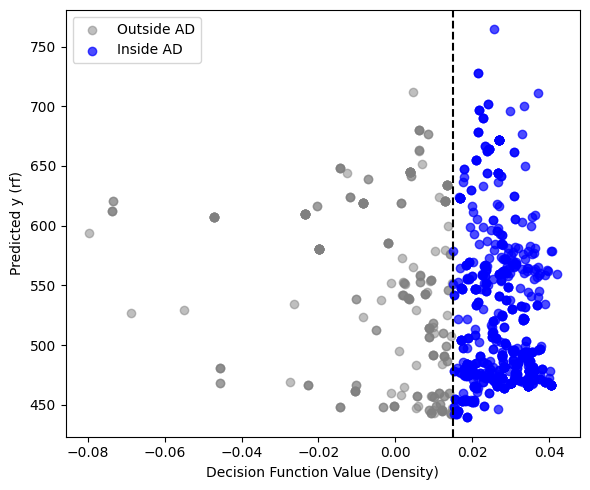

In [11]:
# density ≥ threshold のインデックス
in_ad_index = data_density_test >= threshold
out_ad_index = data_density_test < threshold

plt.figure(figsize=(6, 5))

plt.scatter(
    data_density_test[out_ad_index],
    pred_df["rf"].iloc[out_ad_index],   # ← ここを1次元に
    color="gray", alpha=0.5, label="Outside AD"
)

plt.scatter(
    data_density_test[in_ad_index],
    pred_df["rf"].iloc[in_ad_index],    # ← ここも
    color="blue", alpha=0.7, label="Inside AD"
)

plt.axvline(x=threshold, color="black", linestyle="--")
plt.xlabel("Decision Function Value (Density)")
plt.ylabel("Predicted y (rf)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# モデルの保存
os.makedirs("models/ad", exist_ok=True)

ad_name = f"ocsvm_{descriptor_type}"
artifact_path = f"models/ad/artifact_{ad_name}.joblib"

artifact_ad = {
    "ad_name": ad_name,
    "ad_type": "OCSVM",
    "descriptor_type": descriptor_type,
    "model": ocsvm_model,
    "scaler": ad_scaler,
    "feature_columns": X_train.columns.tolist(),
    "nu": ocsvm_nu,
    "gamma": float(optimal_ocsvm_gamma),
    "threshold_percentile": threshold_percentile,
    "threshold": float(threshold),
}

joblib.dump(artifact_ad, artifact_path)
print("saved:", artifact_path)

saved: models/ad/artifact_ocsvm_mordred_2d.joblib


#### k近傍AD

In [13]:
# kNNモデル作成
k = 5  # 近傍の数（調整可能）
knn_model = NearestNeighbors(metric='euclidean')
knn_model.fit(autoscaled_X_train)

# 学習データの自分を除いた平均近傍距離
dist_train, _ = knn_model.kneighbors(autoscaled_X_train, n_neighbors=k+1)
dist_train_no_self = dist_train[:, 1:]
mean_dist_train = dist_train_no_self.mean(axis=1)

# 距離が大きい25%をAD外とする
threshold = np.percentile(mean_dist_train, 75)

# テストデータの平均近傍距離(相手は学習集合なので、自己は存在しない)
dist_test, _ = knn_model.kneighbors(autoscaled_X_test, n_neighbors=k)
mean_dist_test = dist_test.mean(axis=1)

# 判定(TrueがAD内)
in_ad_knn = mean_dist_test <= threshold

print(f"kNN-AD しきい値: {threshold:.6f}")
print(f"kNN-AD 内サンプル数: {in_ad_knn.sum()} / {len(in_ad_knn)}")

kNN-AD しきい値: 25.175473
kNN-AD 内サンプル数: 780 / 1007


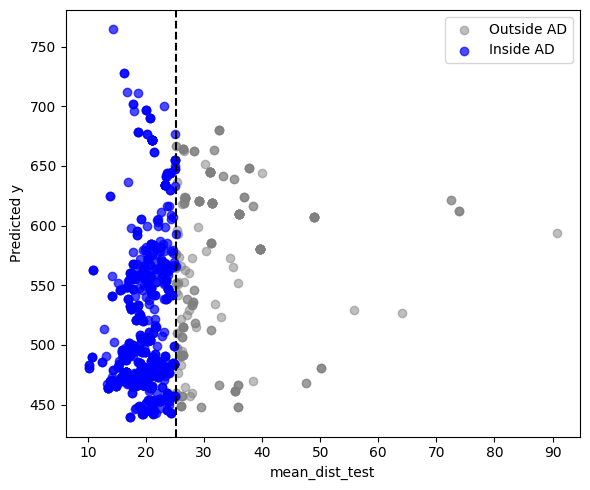

In [14]:
# mean_dist_testがAD閾値より大きいか小さいかでインデックスを分ける
in_ad_index = mean_dist_test <= threshold
out_ad_index = mean_dist_test > threshold

# プロット
plt.figure(figsize=(6, 5))

plt.scatter(
    mean_dist_test[out_ad_index],
    pred_df["rf"].iloc[out_ad_index],   
    color="gray", alpha=0.5, label="Outside AD"
)

plt.scatter(
    mean_dist_test[in_ad_index],
    pred_df["rf"].iloc[in_ad_index],    
    color="blue", alpha=0.7, label="Inside AD"
)

plt.axvline(x=threshold, color='black', linestyle='--')  # しきい値（0）の線
plt.xlabel('mean_dist_test')
plt.ylabel('Predicted y')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# 保存
ad_name = f"knn_{descriptor_type}"
artifact_path = f"models/ad/artifact_{ad_name}.joblib"

artifact_knn = {
    "ad_name": ad_name,
    "ad_type": "kNN",
    "descriptor_type": descriptor_type,
    "model": knn_model,
    "scaler": ad_scaler,  # trainでfitしたStandardScaler（AD用）
    "feature_columns": X_train.columns.tolist(),  # ADに使った特徴量列
    "k": int(k),
    "threshold_percentile": int(threshold_percentile),
    "threshold": float(threshold),
}

joblib.dump(artifact_knn, artifact_path)
print("saved:", artifact_path)

saved: models/ad/artifact_knn_mordred_2d.joblib


#### IsolationForest

In [16]:
# IsolationForestの学習
iso_model = IsolationForest(contamination='auto', random_state=1234)
iso_model.fit(autoscaled_X_train)

# 学習スコア（大きいほど正常/AD内）
train_scores = iso_model.decision_function(autoscaled_X_train)

# 下位25% をAD外にするように後付けでキャリブレーションする
threshold = np.percentile(train_scores, 25)

# テストのAD判定
test_scores = iso_model.decision_function(autoscaled_X_test)
in_ad_iso = test_scores >= threshold

print(f"iso-AD しきい値: {threshold:.6f}")
print(f"iso-AD 内サンプル数: {in_ad_iso.sum()} / {len(in_ad_iso)}")

iso-AD しきい値: 0.057109
iso-AD 内サンプル数: 827 / 1007


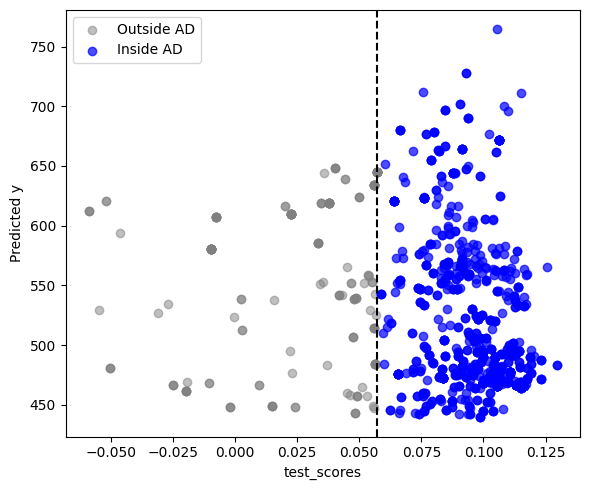

In [17]:
# test_scoresがAD閾値より大きいか小さいかでインデックスを分ける
in_ad_index = test_scores >= threshold
out_ad_index = test_scores < threshold

# プロット
plt.figure(figsize=(6, 5))

plt.scatter(
    test_scores[out_ad_index],
    pred_df["rf"].iloc[out_ad_index],   
    color="gray", alpha=0.5, label="Outside AD"
)

plt.scatter(
    test_scores[in_ad_index],
    pred_df["rf"].iloc[in_ad_index],    
    color="blue", alpha=0.7, label="Inside AD"
)


plt.axvline(x=threshold, color='black', linestyle='--')  # しきい値（0）の線
plt.xlabel('test_scores')
plt.ylabel('Predicted y')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# 保存
ad_name = f"iso_{descriptor_type}"
artifact_path = f"models/ad/artifact_{ad_name}.joblib"

artifact_iso = {
    "ad_name": ad_name,
    "ad_type": "IsolationForest",
    "descriptor_type": descriptor_type,
    "model": iso_model,
    "scaler": ad_scaler,  # trainでfitしたStandardScaler（AD用）
    "feature_columns": X_train.columns.tolist(),  # ADに使った特徴量列
    "threshold_percentile": int(threshold_percentile),
    "threshold": float(threshold),
    "random_state": 1234,
    "contamination": "auto",
}

joblib.dump(artifact_iso, artifact_path)
print("saved:", artifact_path)

saved: models/ad/artifact_iso_mordred_2d.joblib


## 予測結果・AD判定を合わせて保存

In [19]:
# 1) 予測CSVを読む
pred_path = f"outputs/predictions/pred_all_{descriptor_type}.csv"
pred_df = pd.read_csv(pred_path, index_col=0)

# 2) AD判定（bool）を pred_df に追加
# 既に bool 配列がある前提（長さ = pred_df 行数）
pred_df["in_ad_ocsvm"] = np.asarray(in_ad_ocsvm, dtype=bool)
pred_df["in_ad_knn"]   = np.asarray(in_ad_knn, dtype=bool)
pred_df["in_ad_iso"]   = np.asarray(in_ad_iso, dtype=bool)

# 任意：スコアも残したい場合（あれば）
pred_df["ocsvm_density"] = np.asarray(data_density_test)
pred_df["knn_mean_dist"] = np.asarray(mean_dist_test)
pred_df["iso_score"]     = np.asarray(test_scores)

# 3) 上書き保存（同名で保存）
os.makedirs("outputs/predictions", exist_ok=True)
pred_df.to_csv(pred_path, index=True)
print("saved (updated):", pred_path)

saved (updated): outputs/predictions/pred_all_mordred_2d.csv


In [20]:
# 4) 全ADを通過したものだけ抽出して保存
in_all_ads = pred_df["in_ad_ocsvm"] & pred_df["in_ad_knn"] & pred_df["in_ad_iso"]

selected_df = pred_df.loc[in_all_ads].copy()

selected_path = f"outputs/predictions/pred_all_{descriptor_type}_selected.csv"
selected_df.to_csv(selected_path, index=True)

print("selected count:", int(in_all_ads.sum()), "/", len(in_all_ads))
print("saved:", selected_path)

display(selected_df.head())

selected count: 696 / 1007
saved: outputs/predictions/pred_all_mordred_2d_selected.csv


,SMILES,pls,rf,xgb,lgb,nn,in_ad_ocsvm,in_ad_knn,in_ad_iso,ocsvm_density,knn_mean_dist,iso_score
Material,,,,,,,,,,,,
test1,S1N=C2C(=N1)C(=CC=C2C1=CC(=CC=C1)N1C2=C(C=C(C=...,574.088698,575.616496,574.59686,569.175188,542.11620,True,True,True,0.030039,20.984834,0.098734
test2,CC(C=C1)=CC=C1N(C2=CC=C(C)C=C2)C3=CC(SC(C4=C(N...,689.753571,650.265218,705.30540,721.724691,704.73663,True,True,True,0.033854,25.051568,0.093903
test3,CC(C=C1)=CC=C1N(C2=CC=C(C)C=C2)C3=CC(SC(C4=C(N...,639.396080,609.128015,604.32330,604.752896,640.71234,True,True,True,0.036413,24.278644,0.085806
test4,C1(C2=CC=C(N(C3=CC=CC=C3)C4=CC=CC=C4)C=C2)=CC(...,648.206048,636.364989,692.41130,706.147383,623.39404,True,True,True,0.026724,16.895834,0.083282
test5,C1(C2=CC=C(N(C3=CC=CC=C3)C4=CC=CC=C4)C=C2)=CC(...,598.635695,597.930445,605.11330,596.010854,565.26495,True,True,True,0.026751,17.385815,0.085735


## 分子を描写し、出力結果と並べて表示

In [21]:
def show_one_material_from_pred(
    pred_df: pd.DataFrame,
    number: int = None,      # 0 ~ len(pred_df)-1 の位置指定
    material_id: str = None, # index名で指定（Material）
    img_size=(320, 320)
):
    if (number is None) and (material_id is None):
        raise ValueError("number か material_id のどちらかを指定してください。")

    # 対象indexを決める
    if material_id is None:
        if not (0 <= number < len(pred_df)):
            raise ValueError(f"number は 0 〜 {len(pred_df)-1} の範囲で指定してください。")
        idx = pred_df.index[number]
    else:
        if material_id not in pred_df.index:
            raise KeyError(f"{material_id} が pred_df に存在しません。")
        idx = material_id

    row = pred_df.loc[idx]

    # SMILES -> mol
    smiles = row.get("SMILES", None)
    if smiles is None or (isinstance(smiles, float) and pd.isna(smiles)) or str(smiles).strip() == "":
        print(f"[{idx}] SMILES が空です。")
        return

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        print(f"[{idx}] SMILES がRDKitで解釈できません: {smiles}")
        return

    # 描画
    img = Draw.MolToImage(mol, size=img_size, legend=str(idx))
    display(img)

    # 予測値（存在する列だけ表示）
    pred_cols = [c for c in ["pls", "rf", "xgb", "lgb", "nn"] if c in pred_df.columns]
    print("=== Predictions ===")

    pred_vals = []
    for c in pred_cols:
        v = float(row[c])
        pred_vals.append(v)
        print(f"{c:>4}: {v:.3f}")

    # 平均（利用可能なモデルのみ）
    if len(pred_vals) > 0:
        pred_mean = float(sum(pred_vals) / len(pred_vals))
        print(f"{'mean':>4}: {pred_mean:.3f}  (n_models={len(pred_vals)})")
        
    # AD判定（存在する列だけ表示）
    ad_cols = [c for c in ["in_ad_ocsvm", "in_ad_knn", "in_ad_iso"] if c in pred_df.columns]
    print("\n=== AD flags ===")
    for c in ad_cols:
        v = bool(row[c])
        print(f"{c:>11}: {v}")

    # all_ads（その場で計算）
    if len(ad_cols) > 0:
        in_all_ads = True
        for c in ad_cols:
            in_all_ads = in_all_ads and bool(row[c])
        print(f"{'in_all_ads':>11}: {in_all_ads}")

    # おまけ：ADスコア系があれば表示（任意）
    score_cols = [c for c in ["ocsvm_density", "knn_mean_dist", "iso_score"] if c in pred_df.columns]
    if len(score_cols) > 0:
        print("\n=== AD scores ===")
        for c in score_cols:
            print(f"{c:>12}: {row[c]}")

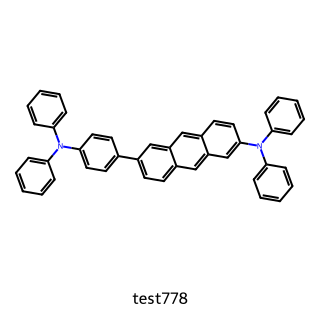

=== Predictions ===
 pls: 494.655
  rf: 491.113
 xgb: 482.161
 lgb: 468.387
  nn: 464.535
mean: 480.170  (n_models=5)

=== AD flags ===
in_ad_ocsvm: True
  in_ad_knn: True
  in_ad_iso: True
 in_all_ads: True

=== AD scores ===
ocsvm_density: 0.027696311403525103
knn_mean_dist: 13.16279915888687
   iso_score: 0.12047228477341931


In [22]:
# 自分の表示したい材料のindexを指定して実行、あるいは好きな数字を指定して実行
number = 777
show_one_material_from_pred(pred_df, number=number)